<a href="https://colab.research.google.com/github/Nurdaulet12/project-1/blob/main/bank_marketing_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Датасет:** Банковский маркетинг

**Цель:** Проанализировать данные клиентов банка, определить основные факторы, влияющие на открытие депозита, и с помощью машинного обучения прогнозировать вероятность открытия депозита клиентом.

**Nurdaulet**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

# DATA UNDERSTANDING

In [ ]:
df = pd.read_csv('bank-full.csv',sep=';')

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
print("\n=== СТРОКА,СТОЛБЕЦ ===")
print(df.shape)


=== СТРОКА,СТОЛБЕЦ ===
(45211, 17)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Проверка нули

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Удаляем дубликаты

In [ ]:
df.drop_duplicates(inplace=True)

# DESCRIPTIVE ANALYSIS

Выведем уникальные значения каждого столбца

In [ ]:
df['job'].value_counts()

,count
job,
blue-collar,9732
management,9458
technician,7597
admin.,5171
services,4154
retired,2264
self-employed,1579
entrepreneur,1487
unemployed,1303


In [ ]:
df['marital'].value_counts()

,count
marital,
married,27214
single,12790
divorced,5207


In [ ]:
df['education'].value_counts()

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


In [ ]:
df['housing'].value_counts()

,count
housing,
yes,25130
no,20081


In [ ]:
df['loan'].value_counts()

,count
loan,
no,37967
yes,7244


In [ ]:
df['contact'].value_counts()

,count
contact,
cellular,29285
unknown,13020
telephone,2906


In [ ]:
df['month'].value_counts()

,count
month,
may,13766
jul,6895
aug,6247
jun,5341
nov,3970
apr,2932
feb,2649
jan,1403
oct,738


In [ ]:
df['poutcome'].value_counts()

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


In [ ]:
df['age'].describe()

,age
count,45211.000000
mean,40.936210
std,10.618762
min,18.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,95.000000


In [ ]:
df['balance'].describe()

,balance
count,45211.000000
mean,1362.272058
std,3044.765829
min,-8019.000000
25%,72.000000
50%,448.000000
75%,1428.000000
max,102127.000000


In [ ]:
df['duration'].describe()

,duration
count,45211.000000
mean,258.163080
std,257.527812
min,0.000000
25%,103.000000
50%,180.000000
75%,319.000000
max,4918.000000


In [ ]:
df['campaign'].describe()

,campaign
count,45211.000000
mean,2.763841
std,3.098021
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,63.000000


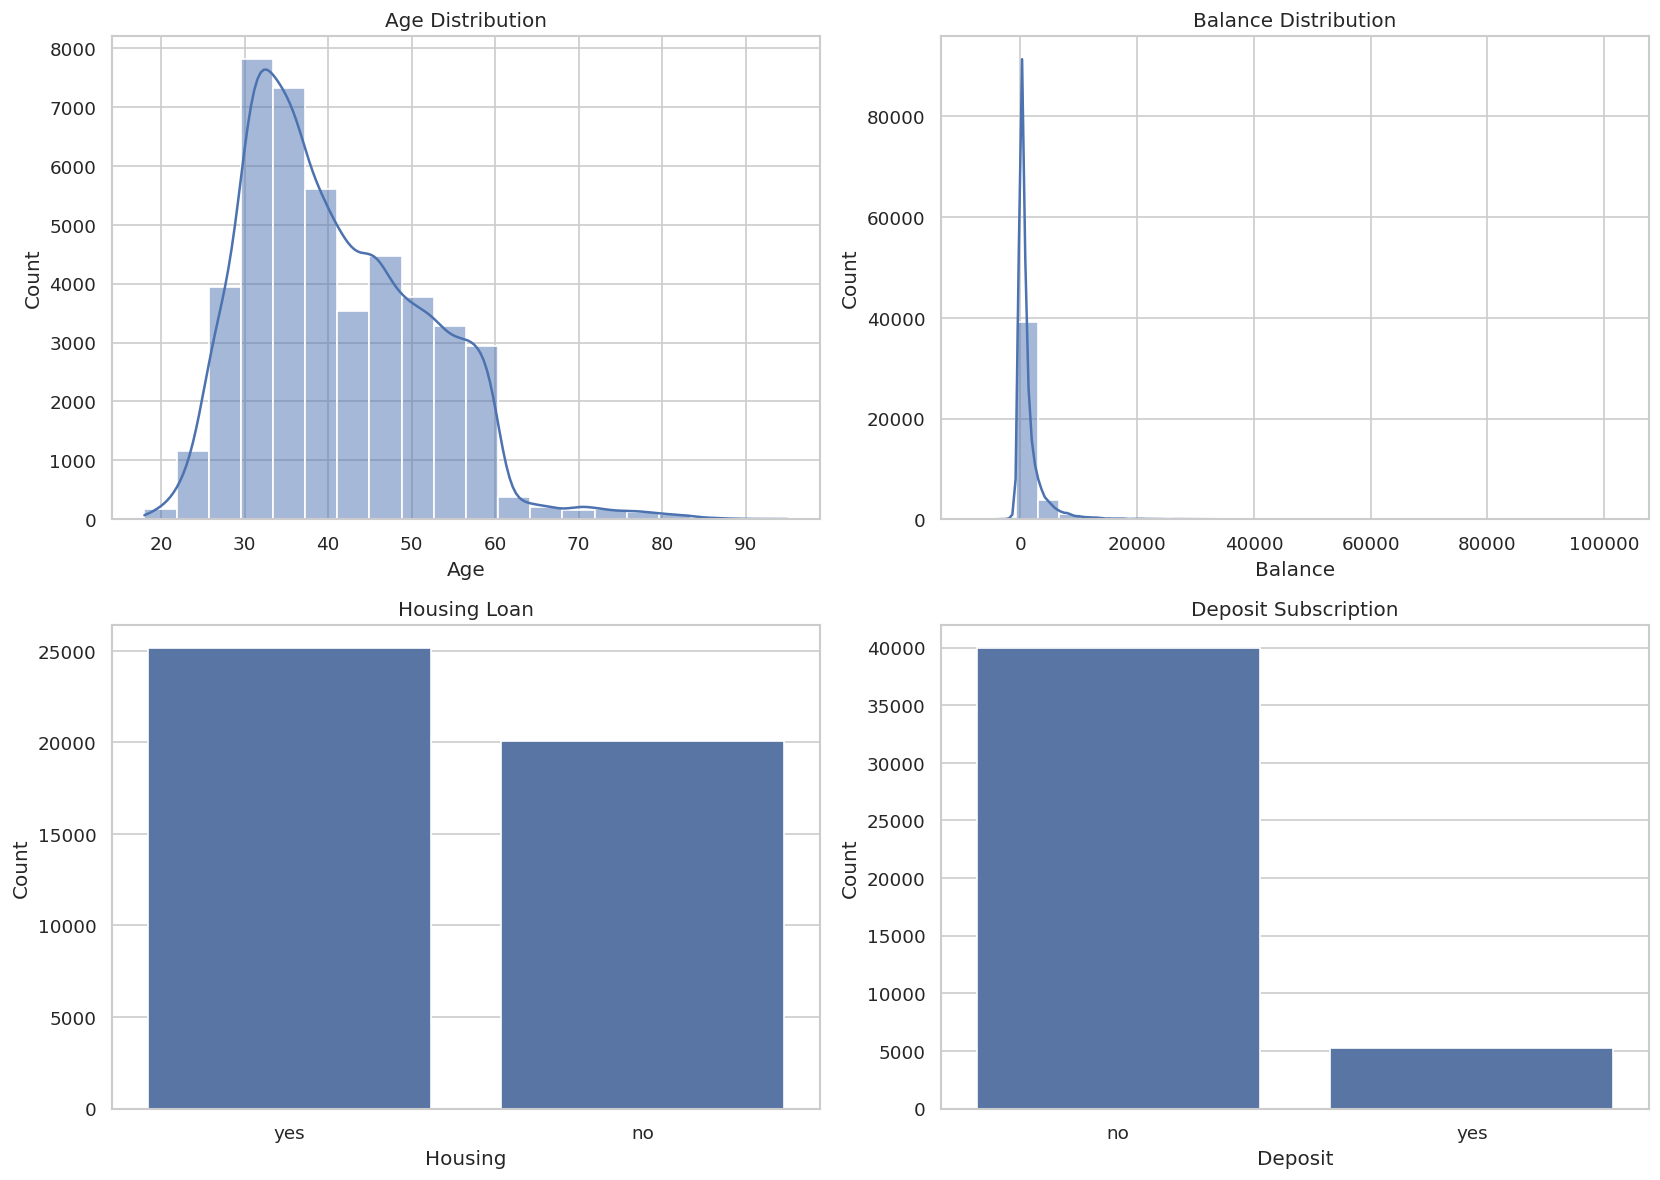

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# 2. Balance
sns.histplot(df['balance'], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title('Balance Distribution')
axes[0,1].set_xlabel('Balance')
axes[0,1].set_ylabel('Count')

# 3. Housing
sns.countplot(data=df, x='housing', ax=axes[1,0])
axes[1,0].set_title('Housing Loan')
axes[1,0].set_xlabel('Housing')
axes[1,0].set_ylabel('Count')

# 4. Deposit
sns.countplot(data=df, x='y', ax=axes[1,1])
axes[1,1].set_title('Deposit Subscription')
axes[1,1].set_xlabel('Deposit')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()


**Возраст(age):** Большинство клиентов находятся в возрасте 30–40 лет. В целом клиентская база представлена людьми от 25 до 60 лет.

**Баланс(balance):** У большинства клиентов небольшой баланс, при этом у отдельных клиентов он значительно выше.

**Жилищный кредит(housing loan):** Более половины клиентов имеют жилищный кредит, но разница между двумя группами небольшая.

**Депозит(deposit):** Большинство клиентов не открыли депозит. Это показывает, что открытие депозита является относительно редким событием в выборке.

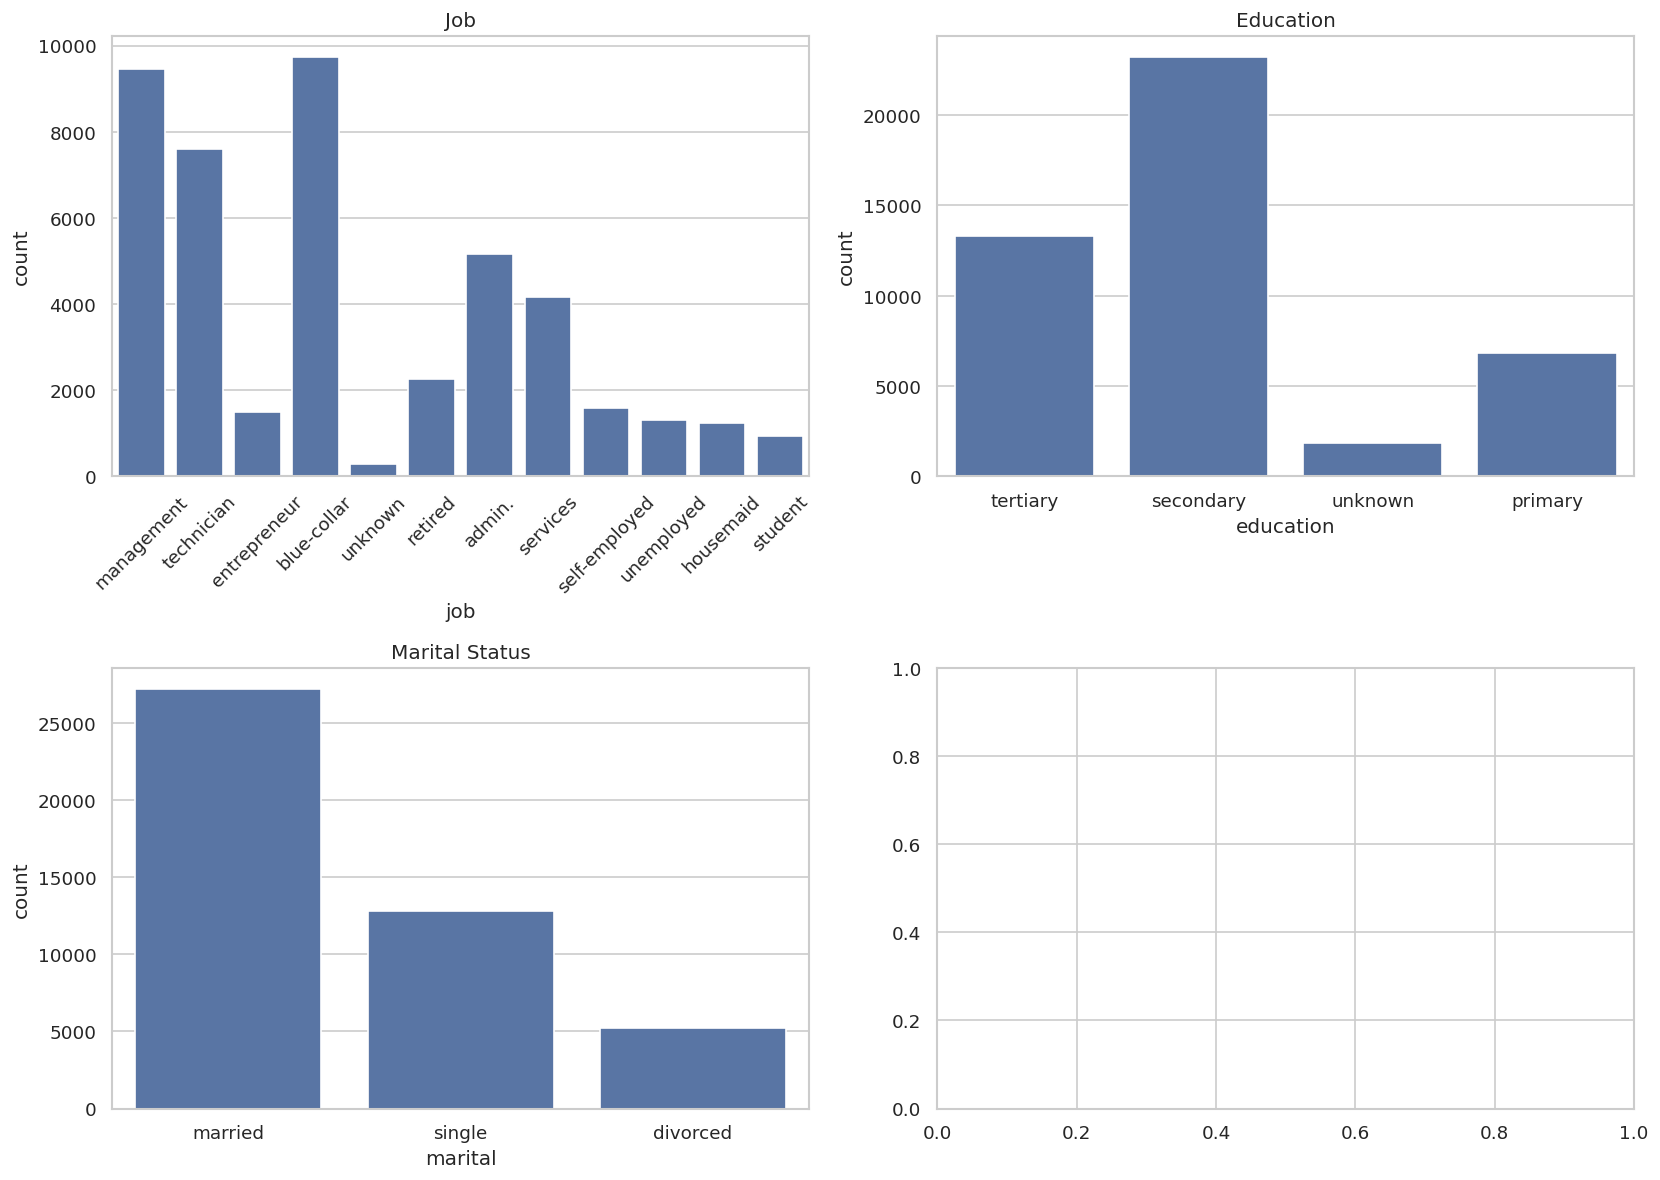

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Job
sns.countplot(data=df, x='job', ax=axes[0,0])
axes[0,0].set_title('Job')
axes[0,0].tick_params(axis='x', rotation=45)

# Education
sns.countplot(data=df, x='education', ax=axes[0,1])
axes[0,1].set_title('Education')

# Marital
sns.countplot(data=df, x='marital', ax=axes[1,0])
axes[1,0].set_title('Marital Status')



plt.tight_layout()
plt.show()

**Job:** Основную часть клиентской базы составляют представители профессий blue-collar, management и technician.

**Education:** Большинство клиентов имеют среднее образование, на втором месте — клиенты с высшим образованием.

**Maritial status:** Большая часть клиентов состоит в браке, тогда как доля разведённых клиентов относительно небольшая.


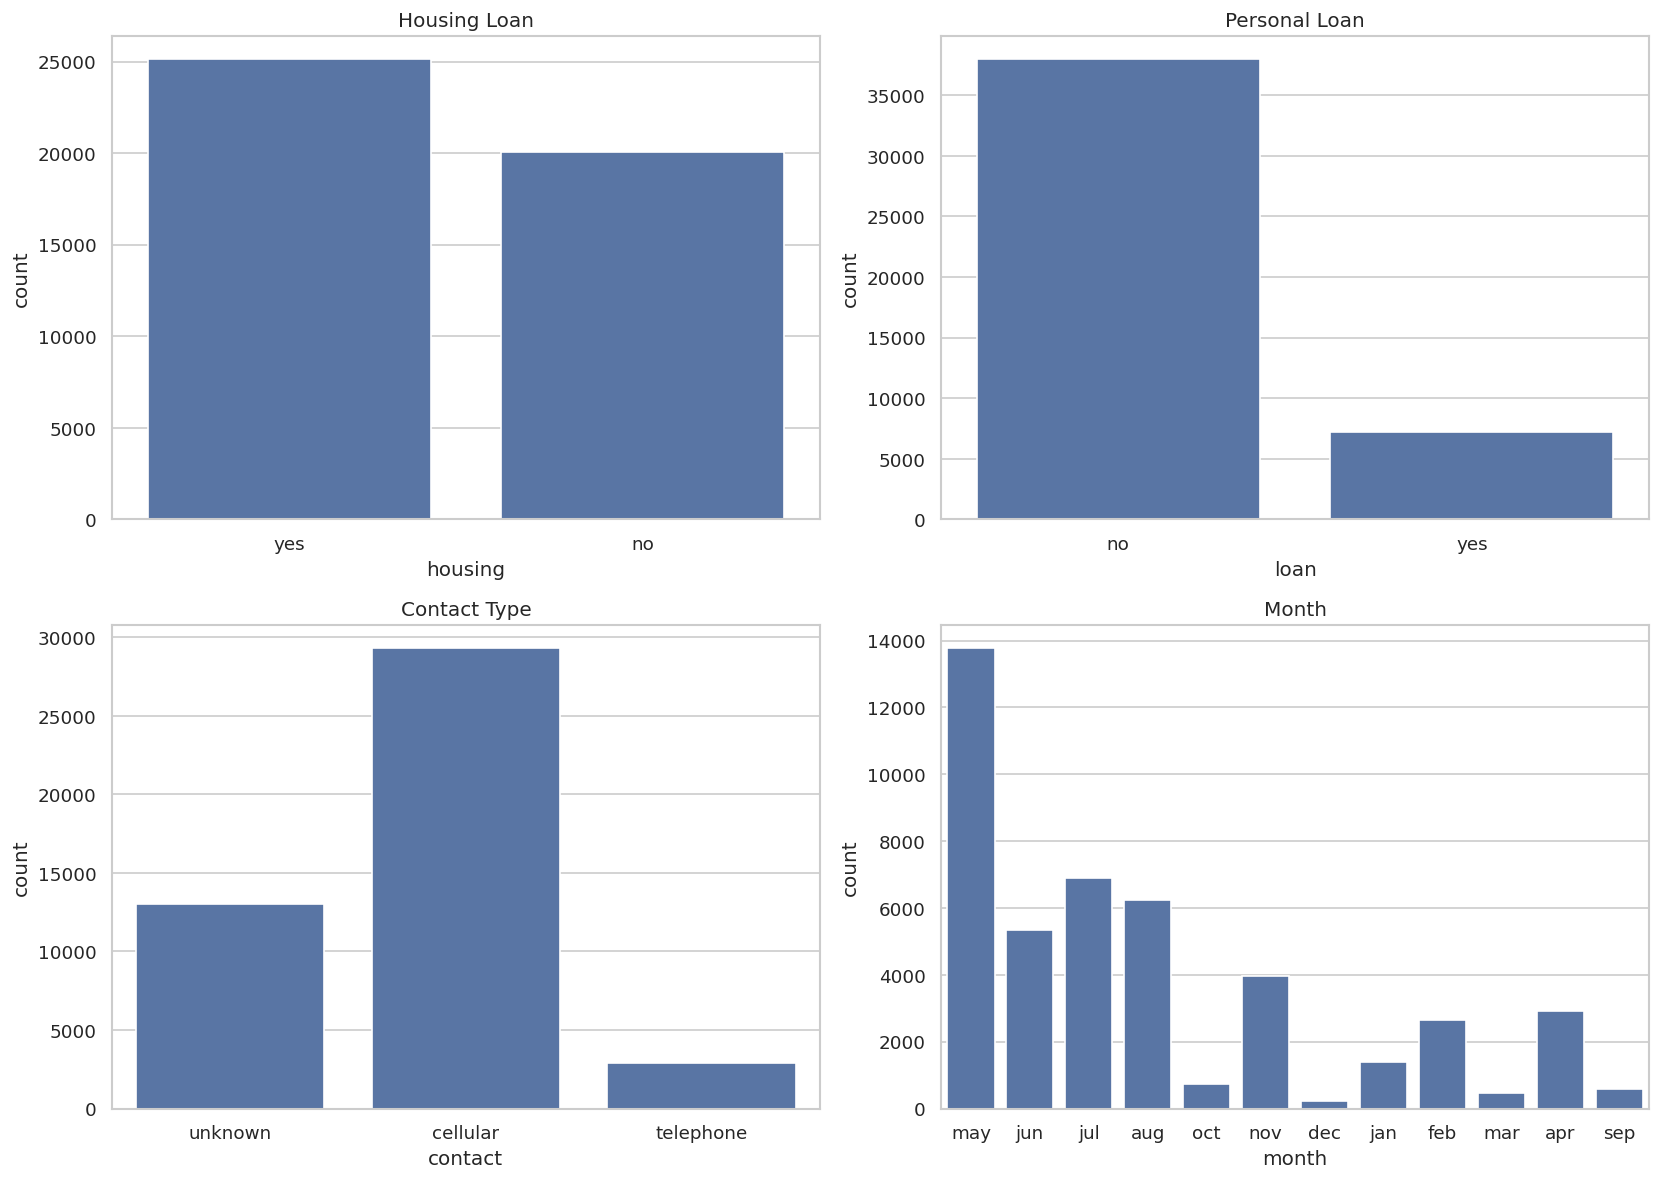

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Housing
sns.countplot(data=df, x='housing', ax=axes[0,0])
axes[0,0].set_title('Housing Loan')

# Personal Loan
sns.countplot(data=df, x='loan', ax=axes[0,1])
axes[0,1].set_title('Personal Loan')

# Contact
sns.countplot(data=df, x='contact', ax=axes[1,0])
axes[1,0].set_title('Contact Type')

# Month
sns.countplot(data=df, x='month', ax=axes[1,1])
axes[1,1].set_title('Month')


plt.tight_layout()
plt.show()

**Loan:** У большинства клиентов отсутствует потребительский кредит.

**Тип контакта:** Примерно с 65% клиентов связывались по мобильному телефону.

**Месяц контакта:** Наибольшее количество контактов с клиентами пришлось на май. В остальные месяцы количество контактов было ниже, особенно в декабре, сентябре и октябре. Это может указывать на то, что маркетинговые акции кампании банка проводились неравномерно в течение года.

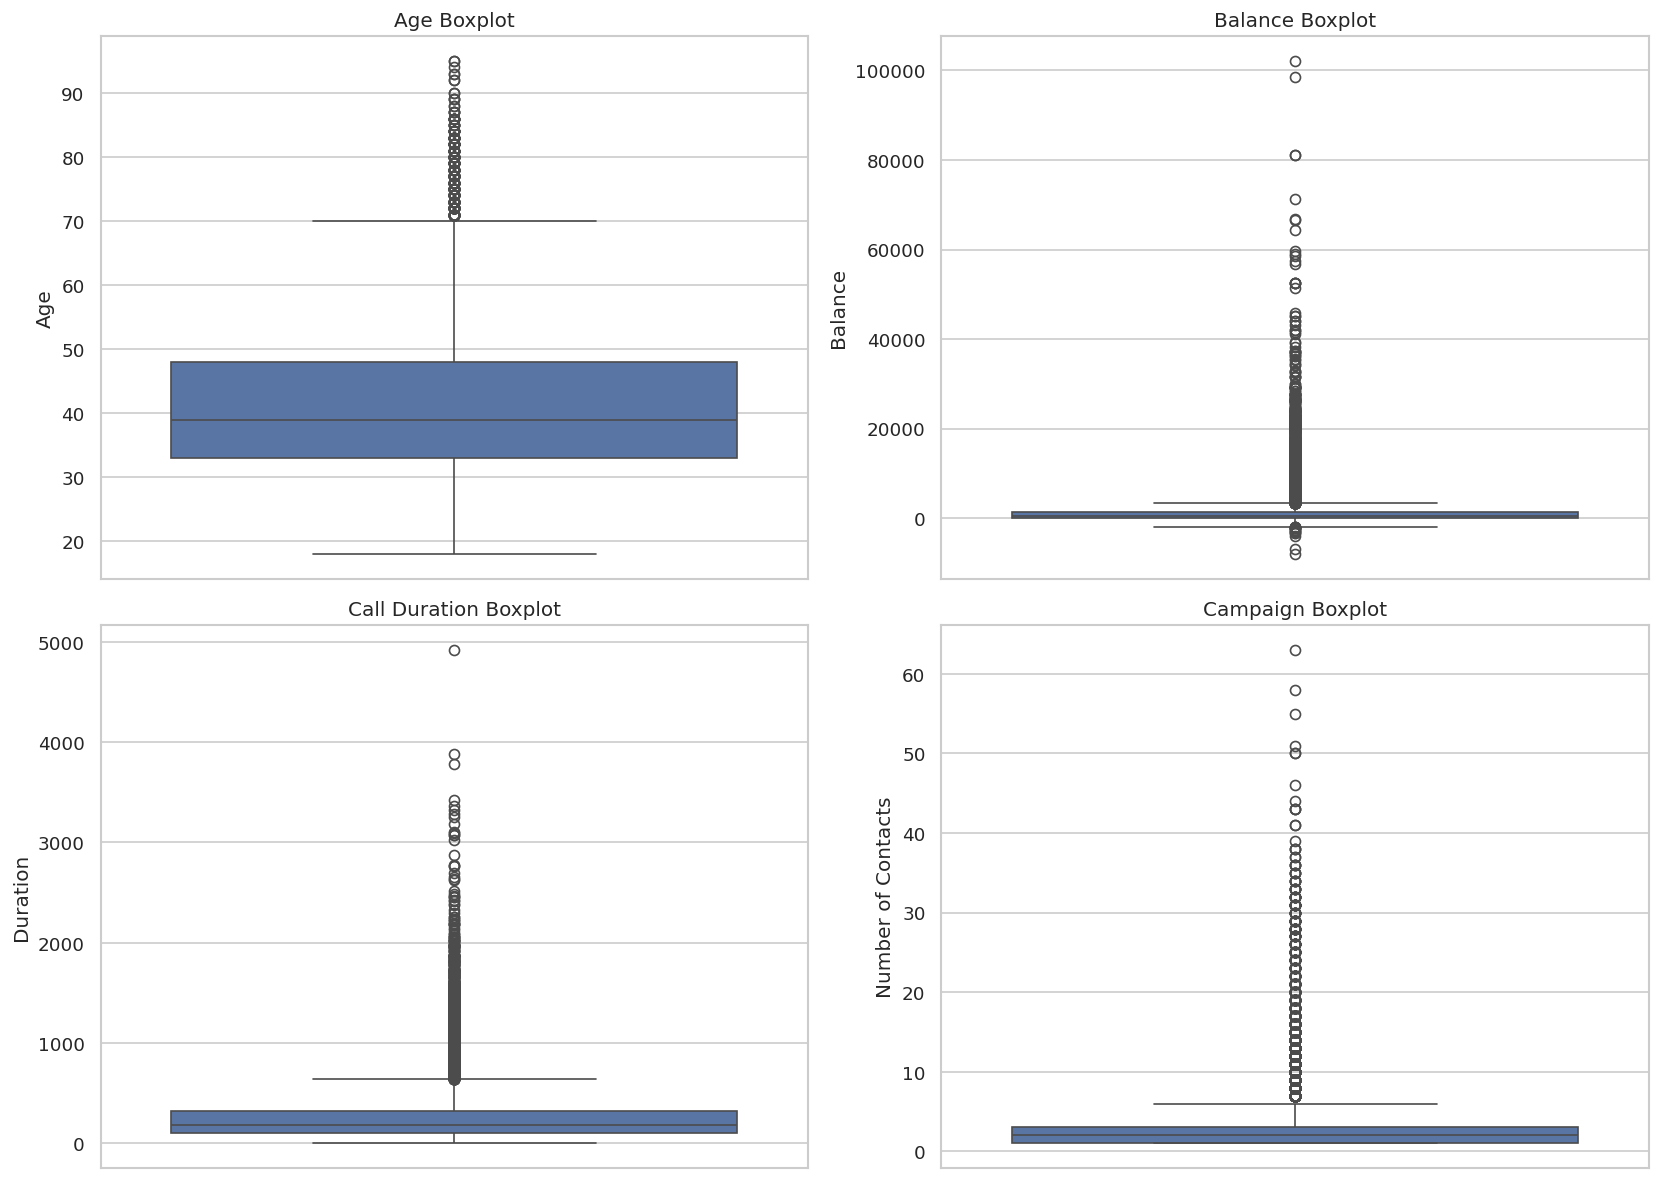

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age
sns.boxplot(y=df['age'], ax=axes[0,0])
axes[0,0].set_title('Age Boxplot')
axes[0,0].set_ylabel('Age')

# Balance
sns.boxplot(y=df['balance'], ax=axes[0,1])
axes[0,1].set_title('Balance Boxplot')
axes[0,1].set_ylabel('Balance')

# Duration
sns.boxplot(y=df['duration'], ax=axes[1,0])
axes[1,0].set_title('Call Duration Boxplot')
axes[1,0].set_ylabel('Duration')

# Campaign
sns.boxplot(y=df['campaign'], ax=axes[1,1])
axes[1,1].set_title('Campaign Boxplot')
axes[1,1].set_ylabel('Number of Contacts')

plt.tight_layout()
plt.show()

# DIAGNOSTIC

In [ ]:
df['y_num'] = df['y'].map({'yes': 1, 'no': 0})

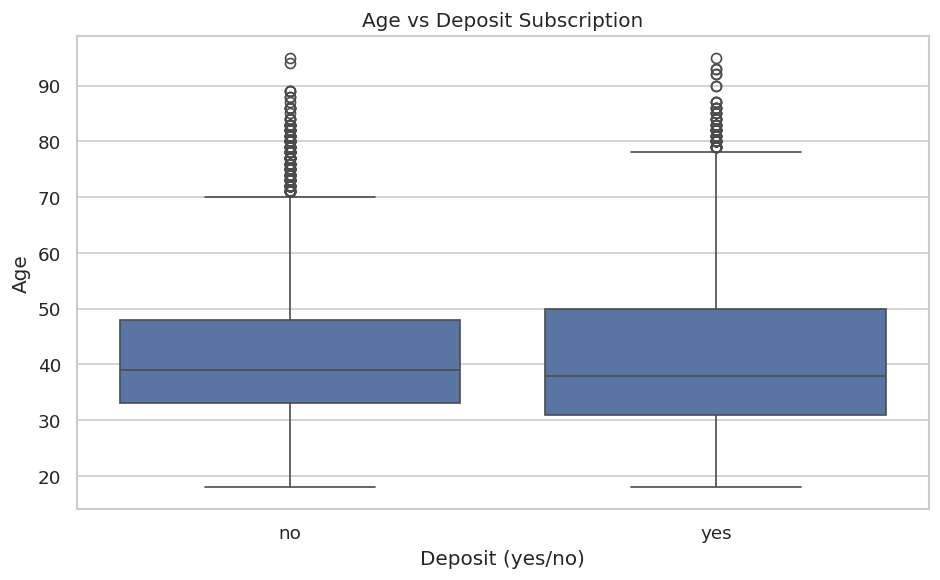

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(data=df, x='y', y='age', ax=ax)

ax.set_title('Age vs Deposit Subscription')
ax.set_xlabel('Deposit (yes/no)')
ax.set_ylabel('Age')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('y')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,40.838986,10.172662,18.0,33.0,39.0,48.0,95.0
yes,5289.0,41.670070,13.497781,18.0,31.0,38.0,50.0,95.0


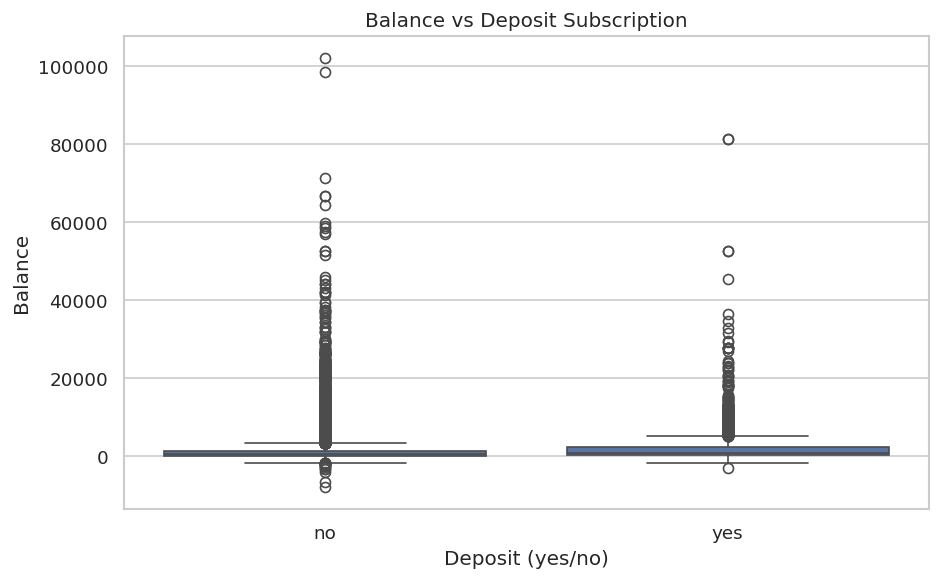

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(data=df, x='y', y='balance', ax=ax)

ax.set_title('Balance vs Deposit Subscription')
ax.set_xlabel('Deposit (yes/no)')
ax.set_ylabel('Balance')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('y')['balance'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,1303.714969,2974.195473,-8019.0,58.0,417.0,1345.0,102127.0
yes,5289.0,1804.267915,3501.104777,-3058.0,210.0,733.0,2159.0,81204.0


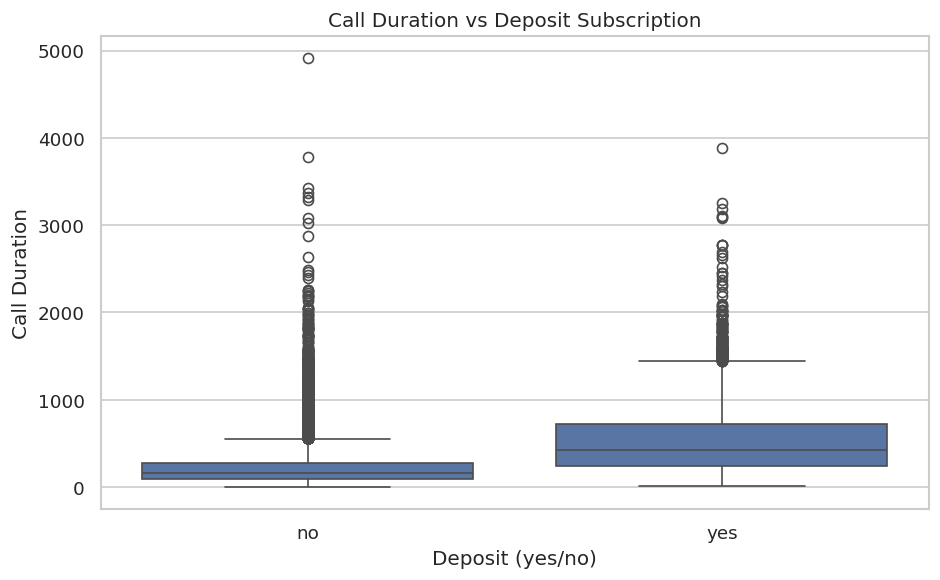

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(data=df, x='y', y='duration', ax=ax)

ax.set_title('Call Duration vs Deposit Subscription')
ax.set_xlabel('Deposit (yes/no)')
ax.set_ylabel('Call Duration')

plt.tight_layout()
plt.show()

In [ ]:
df.groupby('y')['duration'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,221.182806,207.383237,0.0,95.0,164.0,279.0,4918.0
yes,5289.0,537.294574,392.525262,8.0,244.0,426.0,725.0,3881.0


Телефонмен ұзақ сөйлескендердің басым бөлігі депозит ашқан

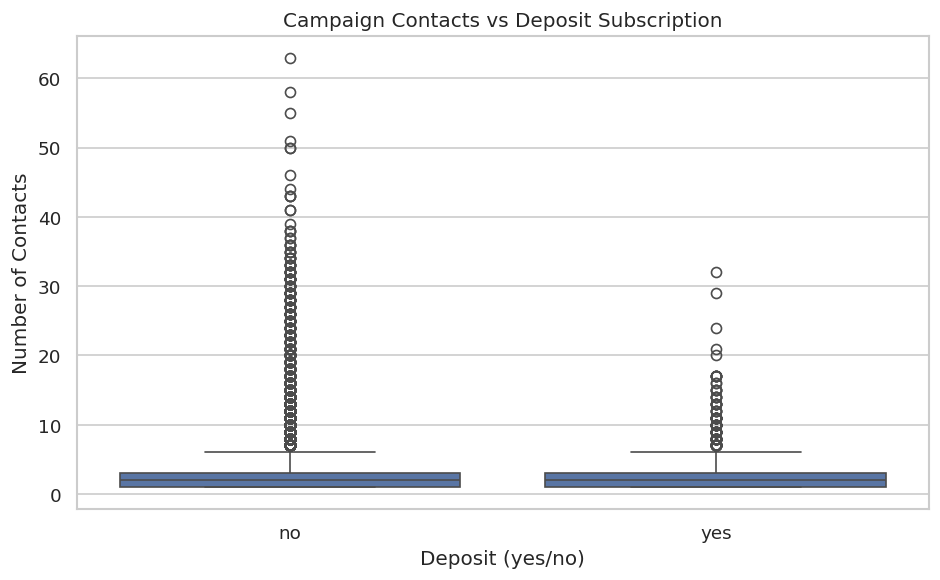

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(data=df, x='y', y='campaign', ax=ax)

ax.set_title('Campaign Contacts vs Deposit Subscription')
ax.set_xlabel('Deposit (yes/no)')
ax.set_ylabel('Number of Contacts')

plt.tight_layout()
plt.show()

**Количество контактов:** Увеличение количества звонков клиенту не оказывает существенного влияния на его решение открыть депозит. Даже после неоднократных обращений вероятность изменения решения остаётся низкой.

In [ ]:
df.groupby('y')['campaign'].describe()

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,2.846350,3.212767,1.0,1.0,2.0,3.0,63.0
yes,5289.0,2.141047,1.921826,1.0,1.0,2.0,3.0,32.0


Влияние

In [ ]:
df['y_num'] = df['y'].map({'yes': 1, 'no': 0})

In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='job',
    aggfunc='mean'
)

print((pivot * 100).round(2))

               y_num
job                 
admin.         12.20
blue-collar     7.27
entrepreneur    8.27
housemaid       8.79
management     13.76
retired        22.79
self-employed  11.84
services        8.88
student        28.68
technician     11.06
unemployed     15.50
unknown        11.81


**job:** Наибольшая вероятность открытия депозита наблюдается среди студентов.

**Blue-collar:** Среди клиентов, работающих в сфере blue-collar, вероятность открытия депозита относительно низкая.

In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='education',
    aggfunc='mean'
)

print((pivot * 100).round(2).sort_values('y_num', ascending=False))

           y_num
education       
tertiary   15.01
unknown    13.57
secondary  10.56
primary     8.63


**Education:** Клиенты с высшим образованием чаще открывают депозит, тогда как среди клиентов с начальным образованием доля открывших депозит значительно ниже. Это может указывать на влияние уровня образования на вероятность открытия депозита.

In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='marital',
    aggfunc='mean'
)

print((pivot * 100).round(2).sort_values('y_num', ascending=False))

          y_num
marital        
single    14.95
divorced  11.95
married   10.12


**Maritial status:** Одинокие клиенты чаще открывают депозит. При этом существенной разницы между женатыми и холостыми клиентами по частоте открытия депозита не наблюдается.

In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='housing',
    aggfunc='mean'
)

print((pivot * 100).round(2))

         y_num
housing       
no        16.7
yes        7.7


**Housing loan:** Можно заметить, что клиенты, имеющие ипотечный кредит, реже открывают депозит.

In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='contact',
    aggfunc='mean'
)

print((pivot * 100).round(2).sort_values('y_num', ascending=False))

           y_num
contact         
cellular   14.92
telephone  13.42
unknown     4.07


In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='month',
    aggfunc='mean'
)

print((pivot * 100).round(2).sort_values('y_num', ascending=False))

       y_num
month       
mar    51.99
dec    46.73
sep    46.46
oct    43.77
apr    19.68
feb    16.65
aug    11.01
jun    10.22
nov    10.15
jan    10.12
jul     9.09
may     6.72


**Месяц контакта:** Несмотря на то, что в мае было совершено наибольшее количество звонков, доля открывших депозит клиентов была самой низкой — 6,72%.
В марте, наоборот, количество звонков было относительно небольшим, однако доля клиентов, открывших депозит, оказалась самой высокой — 51,99%.

In [ ]:
pivot = pd.pivot_table(
    data=df,
    values='y_num',
    index='poutcome',
    aggfunc='mean'
)

print((pivot * 100).round(2).sort_values('y_num', ascending=False))

          y_num
poutcome       
success   64.73
other     16.68
failure   12.61
unknown    9.16


**poutcome:** Клиенты, которые ранее открывали депозит в нашем банке, имеют более высокую вероятность открыть депозит повторно.

# PREDICTIVE

In [ ]:
X = df.drop(['y', 'y_num'], axis=1)
y = df['y_num']

**Целевая переменная:** Выделяем целевую переменную **`y`**, которая показывает, открыл ли клиент депозит. На основе остальных признаков модель будет прогнозировать вероятность открытия депозита.


In [ ]:
X = pd.get_dummies(X, drop_first=True)

**Преобразование данных:** Текстовые категориальные значения преобразуем в числовой формат, чтобы машинное обучение алгоритмі олармен жұмыс істей алуы үшін.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Разделение данных:** Разделяем данные на **обучающую (train)** и **тестовую (test)** выборки. На обучающей выборке модель обучается, а на тестовой — проверяем качество её прогнозов.


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

обучаем модель

In [ ]:
y_pred = model.predict(X_test)

тестируем

In [ ]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


**Оценка модели:** Сравниваем предсказания модели с правильными ответами. Для этого используем метрику **Accuracy**, которая показывает долю правильных прогнозов модели.


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.898595598805706


* **Оценка модели:** Сравниваем предсказания модели с правильными ответами с помощью метрики **Accuracy**. Модель правильно определила результат примерно в **90% случаев**, то есть её точность составила около **90%**.


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7751  201]
 [ 716  375]]


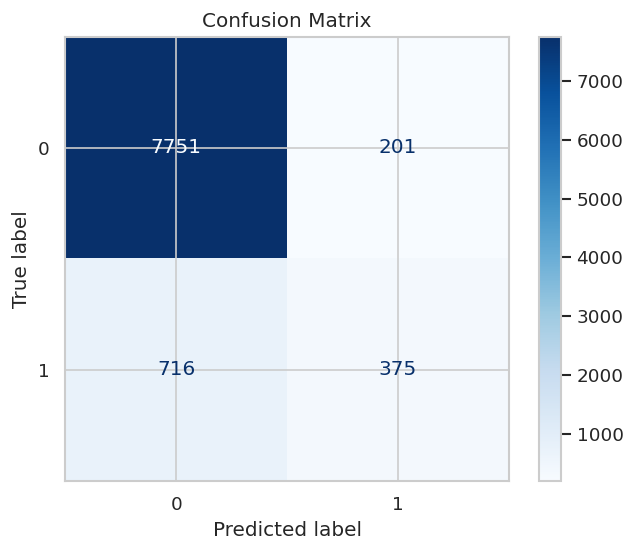

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')

plt.title('Confusion Matrix')
plt.show()

**Confusion Matrix:** Для сравнения реальных ответов клиентов с прогнозами модели построили **Confusion Matrix**. Она позволяет увидеть, сколько ответов модель определила правильно и в каких случаях ошиблась.

precision - вертикально

recall - горизонтально

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



#PRESCRIPTIVE

**Приоритет клиентам с высокой вероятностью открытия депозита**
Клиенты с показателем poutcome = success имеют наиболее высокую вероятность повторного открытия депозита. Поэтому на них стоит направить больше внимания.

**Повышение качества общения с клиентами**
Показатель duration (продолжительность звонка) оказался одним из наиболее значимых факторов, влияющих на открытие депозита. Поэтому важно повышать качество и эффективность телефонных разговоров.

**Сегментация клиентов**
Анализ категориальных признаков показал различия между группами клиентов. Поэтому целесообразно разделять клиентов на сегменты, например студенты, пенсионеры, blue-collar, management и другие группы, и применять к ним разные подходы.